In [10]:
import pandas as pd

In [11]:
regression_data = pd.read_csv("/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/experiments/verdojas_equation/results.nosync/0d2ed26efe3ff2fdc5d51b26dd53a8ba/regression_data_with_equations_2.csv")

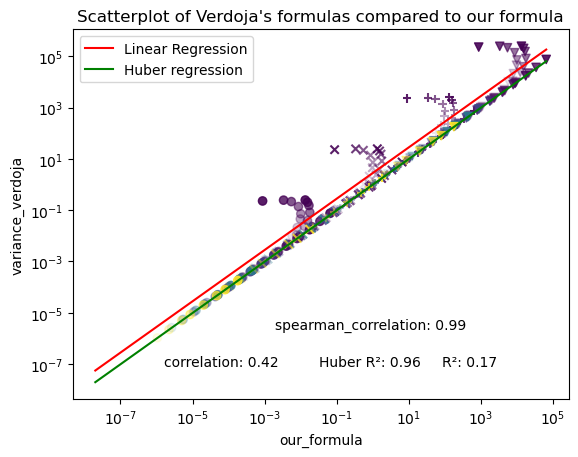

In [6]:
import numpy as np
# make a scatterplot with x axis variance_verdoja and y axis our_formula
import matplotlib.pyplot as plt
symbols = ['o', 'x', '+', 'v', '^', '<', '>', 's', 'd', 'h', 'p', 'P', '*', 'X', '|', '_']
scatter_symbols = [(symbols[i], val) for i, val in enumerate(regression_data['y_mean'].unique())]
for i, (symbol, y_mean) in enumerate(scatter_symbols):
    data_to_plot = regression_data[regression_data['y_mean'] == y_mean]
    alphas = np.arange(0, 1, 1/len(data_to_plot['p'].unique()))
    for alpha, p in zip(alphas, data_to_plot['p'].unique()):
        data_to_plot_p = data_to_plot[data_to_plot['p'] == p]
        plt.scatter(data_to_plot_p['our_formula'], 
                    data_to_plot_p['variance_verdoja'], 
                    c=data_to_plot_p['K'], 
                    marker=symbol, 
                    alpha=alpha)
plt.ylabel('variance_verdoja')
plt.xlabel('our_formula')

# make axis log
plt.xscale('log')
plt.yscale('log')

from sklearn.linear_model import LinearRegression
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance_verdoja'].values
reg = LinearRegression(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='red', label='Linear Regression')
plt.text(0.8, 0.1, ('R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)


from sklearn.linear_model import HuberRegressor
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = HuberRegressor(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='green', label='Huber regression')

plt.text(0.6, 0.1, ('Huber R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)
# calculate correlation
correlation = regression_data['our_formula'].corr(regression_data['variance_verdoja'])
plt.text(0.3, 0.1, ('correlation: %.2f' % (correlation)), ha='center', va='center', transform=plt.gca().transAxes)
# calculate spearman correlation
spearman_correlation = regression_data['our_formula'].corr(regression_data['variance_verdoja'], method='spearman')
plt.text(0.6, 0.2, ('spearman_correlation: %.2f' % (spearman_correlation)), ha='center', va='center', transform=plt.gca().transAxes)

plt.legend()
# plt.ylim(0, 10000)
# plt.xlim(0, 10000)
plt.title("Scatterplot of Verdoja's formulas compared to our formula")
plt.savefig('symbolic_regression_verdoja/scatterplot_variance_verdoja_our_formula.pdf', bbox_inches='tight')
plt.show()

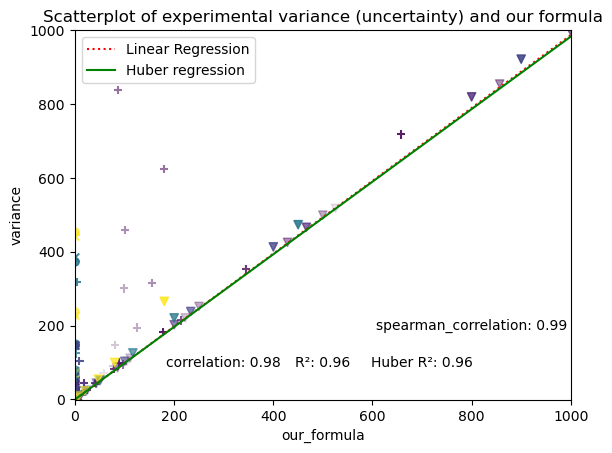

In [13]:
import numpy as np
# make a scatterplot with x axis variance_verdoja and y axis our_formula
import matplotlib.pyplot as plt
symbols = ['o', 'x', '+', 'v', '^', '<', '>', 's', 'd', 'h', 'p', 'P', '*', 'X', '|', '_']
scatter_symbols = [(symbols[i], val) for i, val in enumerate(regression_data['y_mean'].unique())]
for i, (symbol, y_mean) in enumerate(scatter_symbols):
    data_to_plot = regression_data[regression_data['y_mean'] == y_mean]
    alphas = np.arange(0, 1, 1/len(data_to_plot['p'].unique()))
    for alpha, p in zip(alphas, data_to_plot['p'].unique()):
        data_to_plot_p = data_to_plot[data_to_plot['p'] == p]
        plt.scatter(data_to_plot_p['our_formula'], 
                    data_to_plot_p['variance'], 
                    c=data_to_plot_p['K'], 
                    marker=symbol, 
                    alpha=alpha)
plt.xlabel('our_formula')
plt.ylabel('variance')
plt.title('Scatterplot of variance and our_formula')
# make axis log
# plt.xscale('log')
# plt.yscale('log') 

# calculate correlation
correlation = regression_data['our_formula'].corr(regression_data['variance'])
# draw linear regression
from sklearn.linear_model import LinearRegression
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = LinearRegression(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='red', linestyle=':', label='Linear Regression')
plt.text(0.5, 0.1, ('R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

# do a lasso regression now
from sklearn.linear_model import HuberRegressor
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = HuberRegressor(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='green', label='Huber regression')
# print R^2
plt.text(0.7, 0.1, ('Huber R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

plt.text(0.3, 0.1, ('correlation: %.2f' % (correlation)), ha='center', va='center', transform=plt.gca().transAxes)
spearman_correlation = regression_data['our_formula'].corr(regression_data['variance_verdoja'], method='spearman')
plt.text(0.8, 0.2, ('spearman_correlation: %.2f' % (spearman_correlation)), ha='center', va='center', transform=plt.gca().transAxes)

plt.legend()
plt.ylim(-0.5, 1000)
plt.xlim(-0.5, 1000)
plt.title("Scatterplot of experimental variance (uncertainty) and our formula")
# plt.savefig('symbolic_regression_verdoja/scatterplot_variance_our_formula.pdf', bbox_inches='tight')
plt.show()

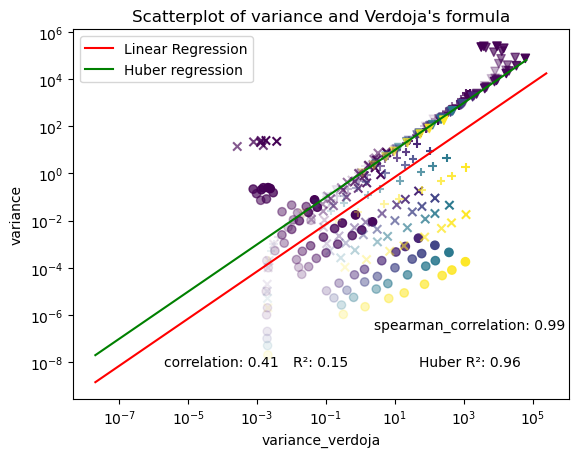

In [13]:
import numpy as np
# make a scatterplot with x axis variance_verdoja and y axis our_formula
import matplotlib.pyplot as plt
symbols = ['o', 'x', '+', 'v', '^', '<', '>', 's', 'd', 'h', 'p', 'P', '*', 'X', '|', '_']
scatter_symbols = [(symbols[i], val) for i, val in enumerate(regression_data['y_mean'].unique())]
for i, (symbol, y_mean) in enumerate(scatter_symbols):
    data_to_plot = regression_data[regression_data['y_mean'] == y_mean]
    alphas = np.arange(0.1, 1, 1/len(data_to_plot['p'].unique()))
    for alpha, p in zip(alphas, data_to_plot['p'].unique()):
        data_to_plot_p = data_to_plot[data_to_plot['p'] == p]
        plt.scatter(data_to_plot_p['variance'], 
                    data_to_plot_p['variance_verdoja'], 
                    c=data_to_plot_p['K'], 
                    marker=symbol, 
                    alpha=alpha)
plt.xlabel('variance_verdoja')
plt.ylabel('variance')
plt.title('Scatterplot of variance and variance_verdoja')
# make axis log
plt.xscale('log')
plt.yscale('log')

# calculate correlation
correlation = regression_data['variance_verdoja'].corr(regression_data['variance'])

from sklearn.linear_model import LinearRegression
X = regression_data['variance_verdoja'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = LinearRegression(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='red',  label='Linear Regression')
# print R^2
plt.text(0.5, 0.1, ('R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

from sklearn.linear_model import HuberRegressor
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = HuberRegressor(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='green', label='Huber regression')
# print R^2
plt.text(0.8, 0.1, ('Huber R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

plt.text(0.3, 0.1, ('correlation: %.2f' % (correlation)), ha='center', va='center', transform=plt.gca().transAxes)
spearman_correlation = regression_data['our_formula'].corr(regression_data['variance_verdoja'], method='spearman')
plt.text(0.8, 0.2, ('spearman_correlation: %.2f' % (spearman_correlation)), ha='center', va='center', transform=plt.gca().transAxes)

plt.legend()
# plt.ylim(0, 10000)
# plt.xlim(0, 10000)
plt.title("Scatterplot of variance and Verdoja's formula")
plt.savefig('symbolic_regression_verdoja/scatterplot_variance_variance_verdoja.pdf', bbox_inches='tight')
plt.show()

# Using Log Likelihood as well

Here I have load data that is calculated on the test set!

In [7]:
import pandas as pd
regression_data = pd.read_csv("/Users/leonardoalchieri/Desktop/GIT/MCDropoutHyperparameterAnalysis/experiments/verdojas_equation/results.nosync/04b085ab987d5e4eeebcb55f59c7cb53/regression_data_with_equations_test.csv")

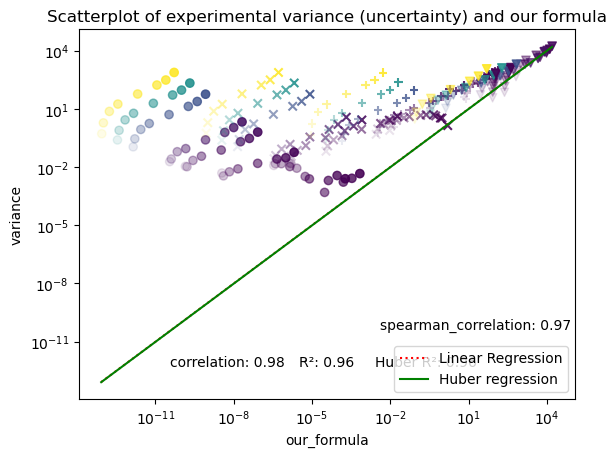

In [8]:
import numpy as np
# make a scatterplot with x axis variance_verdoja and y axis our_formula
import matplotlib.pyplot as plt
symbols = ['o', 'x', '+', 'v', '^', '<', '>', 's', 'd', 'h', 'p', 'P', '*', 'X', '|', '_']
scatter_symbols = [(symbols[i], val) for i, val in enumerate(regression_data['y_mean'].unique())]
for i, (symbol, y_mean) in enumerate(scatter_symbols):
    data_to_plot = regression_data[regression_data['y_mean'] == y_mean]
    alphas = np.arange(0, 1, 1/len(data_to_plot['p'].unique()))
    for alpha, p in zip(alphas, data_to_plot['p'].unique()):
        data_to_plot_p = data_to_plot[data_to_plot['p'] == p]
        plt.scatter(data_to_plot_p['our_formula'], 
                    data_to_plot_p['variance'], 
                    c=data_to_plot_p['K'], 
                    marker=symbol, 
                    alpha=alpha)
plt.xlabel('our_formula')
plt.ylabel('variance')
plt.title('Scatterplot of variance and our_formula')
# make axis log
plt.xscale('log')
plt.yscale('log') 

# calculate correlation
correlation = regression_data['our_formula'].corr(regression_data['variance'])
# draw linear regression
from sklearn.linear_model import LinearRegression
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = LinearRegression(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='red', linestyle=':', label='Linear Regression')
plt.text(0.5, 0.1, ('R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

# do a lasso regression now
from sklearn.linear_model import HuberRegressor
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = HuberRegressor(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='green', label='Huber regression')
# print R^2
plt.text(0.7, 0.1, ('Huber R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

plt.text(0.3, 0.1, ('correlation: %.2f' % (correlation)), ha='center', va='center', transform=plt.gca().transAxes)
spearman_correlation = regression_data['our_formula'].corr(regression_data['variance_verdoja'], method='spearman')
plt.text(0.8, 0.2, ('spearman_correlation: %.2f' % (spearman_correlation)), ha='center', va='center', transform=plt.gca().transAxes)

plt.legend()
# plt.ylim(0, 10000)
# plt.xlim(0, 10000)
plt.title("Scatterplot of experimental variance (uncertainty) and our formula")
# plt.savefig('symbolic_regression_verdoja/scatterplot_variance_our_formula.pdf', bbox_inches='tight')
plt.show()

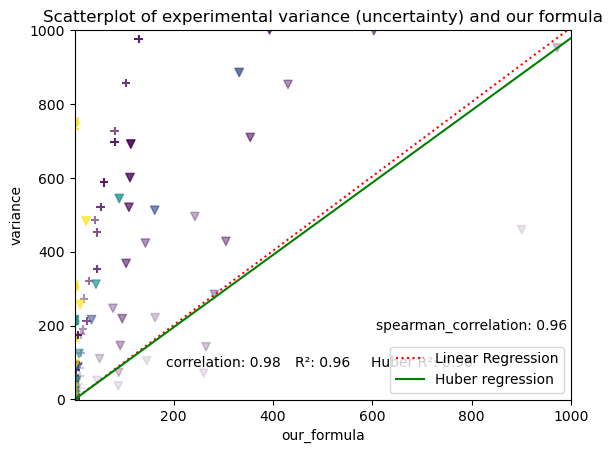

In [3]:
import numpy as np
# make a scatterplot with x axis variance_verdoja and y axis our_formula
import matplotlib.pyplot as plt
symbols = ['o', 'x', '+', 'v', '^', '<', '>', 's', 'd', 'h', 'p', 'P', '*', 'X', '|', '_']
scatter_symbols = [(symbols[i], val) for i, val in enumerate(regression_data['y_mean'].unique())]
for i, (symbol, y_mean) in enumerate(scatter_symbols):
    data_to_plot = regression_data[regression_data['y_mean'] == y_mean]
    alphas = np.arange(0, 1, 1/len(data_to_plot['p'].unique()))
    for alpha, p in zip(alphas, data_to_plot['p'].unique()):
        data_to_plot_p = data_to_plot[data_to_plot['p'] == p]
        plt.scatter(data_to_plot_p['our_formula'], 
                    data_to_plot_p['variance'], 
                    c=data_to_plot_p['K'], 
                    marker=symbol, 
                    alpha=alpha)
plt.xlabel('our_formula')
plt.ylabel('variance')
plt.title('Scatterplot of variance and our_formula')
# make axis log
# plt.xscale('log')
# plt.yscale('log') 

# calculate correlation
correlation = regression_data['our_formula'].corr(regression_data['variance'])
# draw linear regression
from sklearn.linear_model import LinearRegression
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = LinearRegression(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='red', linestyle=':', label='Linear Regression')
plt.text(0.5, 0.1, ('R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

# do a lasso regression now
from sklearn.linear_model import HuberRegressor
X = regression_data['our_formula'].values.reshape(-1, 1)
y = regression_data['variance'].values
reg = HuberRegressor(fit_intercept=False).fit(X, y)
# sort X
X = X.reshape(-1)
sorting_order = np.argsort(X)
X = X[sorting_order]
y = y[sorting_order]
plt.plot(X, reg.predict(X.reshape(-1, 1)), color='green', label='Huber regression')
# print R^2
plt.text(0.7, 0.1, ('Huber R²: %.2f' % (reg.score(X.reshape(-1, 1), y))), ha='center', va='center', transform=plt.gca().transAxes)

plt.text(0.3, 0.1, ('correlation: %.2f' % (correlation)), ha='center', va='center', transform=plt.gca().transAxes)
spearman_correlation = regression_data['our_formula'].corr(regression_data['variance_verdoja'], method='spearman')
plt.text(0.8, 0.2, ('spearman_correlation: %.2f' % (spearman_correlation)), ha='center', va='center', transform=plt.gca().transAxes)

plt.legend()
plt.ylim(-0.5, 1000)
plt.xlim(0.5, 1000)
plt.title("Scatterplot of experimental variance (uncertainty) and our formula")
# plt.savefig('symbolic_regression_verdoja/scatterplot_variance_our_formula.pdf', bbox_inches='tight')
plt.show()